In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

In [ ]:
import os

print(os.listdir())

['.config', 'diabetes.csv', 'sample_data']


In [ ]:
df = pd.read_csv("diabetes.csv")

print("Pima Indians Diabetes Dataset Sample:")
print(df.head())

Pima Indians Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
# Linear Regression - Glucose vs BMI

X = df[["Glucose"]]
Y = df["BMI"]

model = LinearRegression()

# Train the model
model.fit(X, Y)

# Predict BMI
Y_pred = model.predict(X)

# Calculate R2 Score
r2 = r2_score(Y, Y_pred)

print("Linear Regression (Predicting BMI using Glucose):")
print("R2 Score:", round(r2, 4))

Linear Regression (Predicting BMI using Glucose):
R2 Score: 0.0489


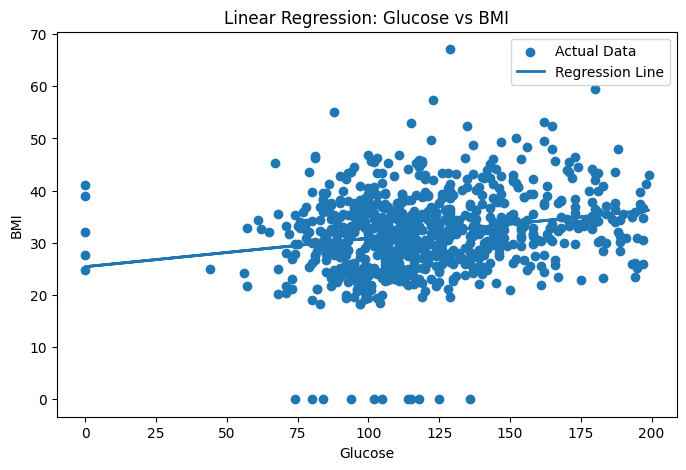

In [ ]:
# Plot Linear Regression

plt.figure(figsize=(8, 5))

plt.scatter(X["Glucose"], Y, label="Actual Data")
plt.plot(X["Glucose"], Y_pred, linewidth=2, label="Regression Line")

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Linear Regression: Glucose vs BMI")
plt.legend()

plt.show()

In [ ]:
# Select features and target

features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"

X = df[features]
Y = df[target]

print("Features:")
print(X.head())

print("\nTarget:")
print(Y.head())

Features:
   Glucose  BloodPressure   BMI  Age
0      148             72  33.6   50
1       85             66  26.6   31
2      183             64  23.3   32
3       89             66  28.1   21
4      137             40  43.1   33

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [ ]:
# Split dataset into training and testing data

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 614
Testing Samples: 154


In [ ]:
# Create and train Logistic Regression model

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, Y_train)

# Predict test data
Y_pred_logistic = logistic_model.predict(X_test)

In [ ]:
# Calculate Accuracy

accuracy = accuracy_score(Y_test, Y_pred_logistic)

print("Logistic Regression (Predicting Outcome)")
print("Features:", features)
print("Accuracy Score:", round(accuracy, 4))
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Logistic Regression (Predicting Outcome)
Features: ['Glucose', 'BloodPressure', 'BMI', 'Age']
Accuracy Score: 0.7403
Accuracy Percentage: 74.03 %


In [ ]:
# Compare Actual and Predicted Outcomes

results = pd.DataFrame({
    "Actual Outcome": Y_test.values,
    "Predicted Outcome": Y_pred_logistic
})

print(results.head(20))

    Actual Outcome  Predicted Outcome
0                0                  0
1                0                  0
2                0                  0
3                0                  0
4                0                  0
5                0                  1
6                0                  0
7                0                  1
8                0                  1
9                0                  1
10               1                  0
11               0                  1
12               1                  0
13               0                  0
14               0                  0
15               1                  0
16               0                  0
17               0                  0
18               1                  1
19               1                  1


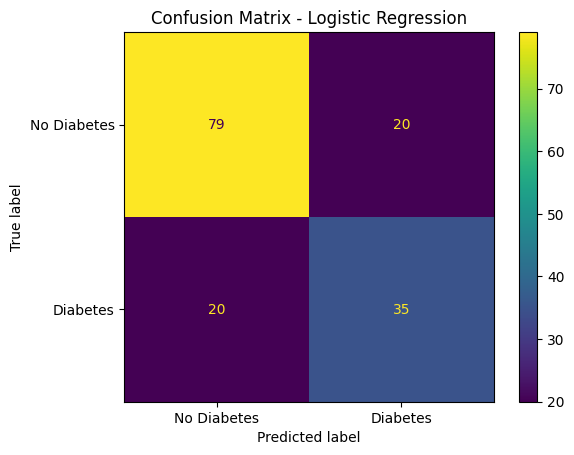

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, Y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
print("----- FINAL RESULTS -----")

print("\nLinear Regression:")
print("Glucose vs BMI")
print("R2 Score:", round(r2, 4))

print("\nLogistic Regression:")
print("Features: Glucose, BloodPressure, BMI, Age")
print("Accuracy Score:", round(accuracy, 4))
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

----- FINAL RESULTS -----

Linear Regression:
Glucose vs BMI
R2 Score: 0.0489

Logistic Regression:
Features: Glucose, BloodPressure, BMI, Age
Accuracy Score: 0.7403
Accuracy Percentage: 74.03 %


In [ ]:
print("INTERPRETATION:")

print("""
Linear Regression was used to analyze the relationship between
Glucose and BMI. The R2 score indicates how strongly Glucose
explains the variation in BMI.

Logistic Regression was used to predict diabetes Outcome using
Glucose, BloodPressure, BMI, and Age.

The accuracy score indicates the proportion of test samples
correctly classified by the Logistic Regression model.
""")

INTERPRETATION:

Linear Regression was used to analyze the relationship between
Glucose and BMI. The R2 score indicates how strongly Glucose
explains the variation in BMI.

Logistic Regression was used to predict diabetes Outcome using
Glucose, BloodPressure, BMI, and Age.

The accuracy score indicates the proportion of test samples
correctly classified by the Logistic Regression model.



In [ ]:
print("""
RESULT:

Bivariate analysis was successfully performed on the Pima Indians
Diabetes Dataset.

Linear Regression was used to study the relationship between
Glucose and BMI, and its performance was evaluated using the R2 score.

Logistic Regression was used to predict diabetes presence using
Glucose, BloodPressure, BMI, and Age, and its performance was
evaluated using the Accuracy Score.

Thus, Linear and Logistic Regression models were successfully
implemented and analyzed.
""")


RESULT:

Bivariate analysis was successfully performed on the Pima Indians
Diabetes Dataset.

Linear Regression was used to study the relationship between
Glucose and BMI, and its performance was evaluated using the R2 score.

Logistic Regression was used to predict diabetes presence using
Glucose, BloodPressure, BMI, and Age, and its performance was
evaluated using the Accuracy Score.

Thus, Linear and Logistic Regression models were successfully
implemented and analyzed.

